# Import Library + Seed

In [1]:
import os
import shutil
import random
import hashlib
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    _HAS_SNS = True
except ImportError:
    _HAS_SNS = False

from sklearn.model_selection import train_test_split
from tqdm import tqdm
from PIL import Image, UnidentifiedImageError

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Konfigurasi Path

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "data" / "raw").exists():
            return p
    raise FileNotFoundError(
        "Tidak menemukan root proyek (indikator: folder data/raw). "
        "Jalankan notebook dari dalam proyek atau pastikan struktur folder benar."
    )

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = find_project_root(CURRENT_DIR)

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "data" / "split"

print(f"Membaca data dari: {RAW_DATA_DIR}")

CLASSES = sorted([p.name for p in RAW_DATA_DIR.iterdir() if p.is_dir()])
if not CLASSES:
    raise ValueError(f"ERROR: Tidak ada subfolder kelas di {RAW_DATA_DIR}.")
print(f"Ditemukan {len(CLASSES)} kelas: {CLASSES}")

Membaca data dari: C:\Users\dwork\Downloads\Garbage_Classification_Thesis\data\raw
Ditemukan 12 kelas: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


# EDA & Data Gathering

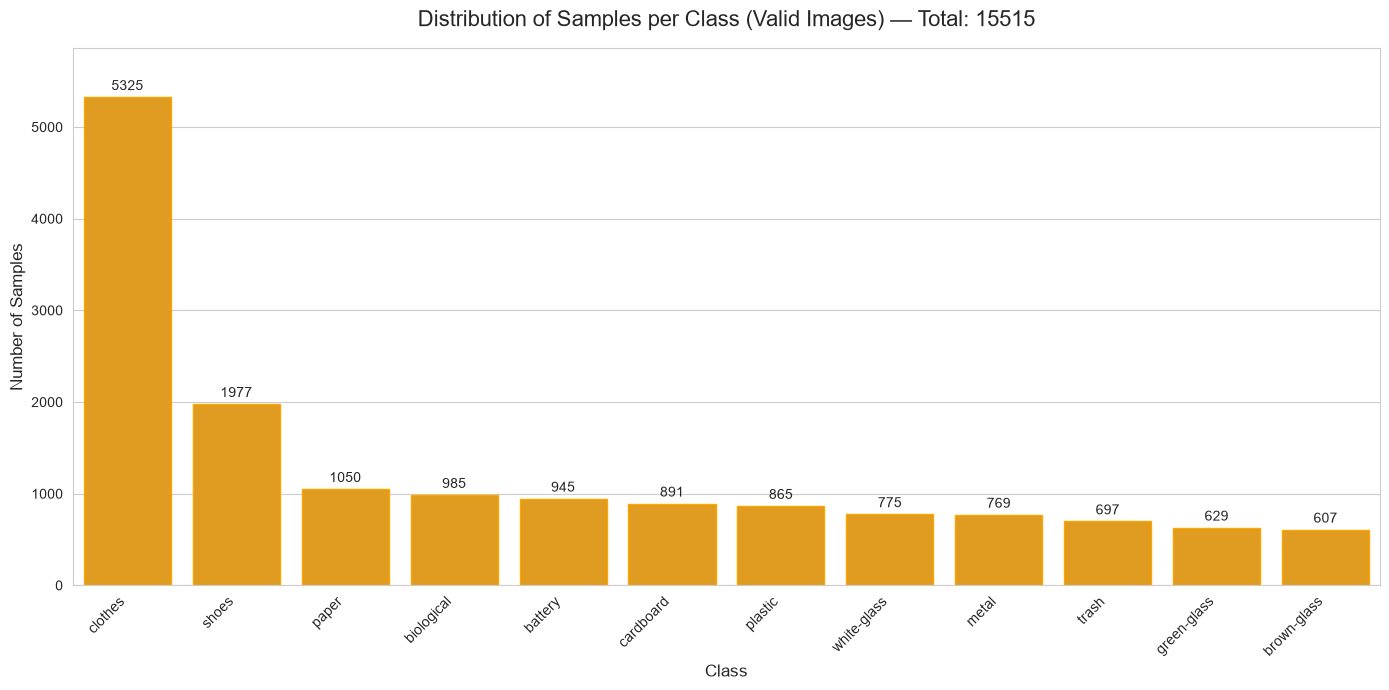

Grafik berhasil disimpan di: C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\figures\preparation\class_distribution.png


In [3]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff", ".webp"}

def is_valid_image(path: Path) -> bool:
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except (UnidentifiedImageError, OSError):
        return False

class_counts = {}
all_files, all_labels = [], []

for c in CLASSES:
    class_dir = (RAW_DATA_DIR / c).resolve()

    if not class_dir.exists() or not class_dir.is_dir():
        class_counts[c] = 0
        continue

    candidates = [
        p for p in class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ]

    valid_files = [p for p in candidates if is_valid_image(p)]

    class_counts[c] = len(valid_files)
    for p in valid_files:
        all_files.append(str(p))
        all_labels.append(c)

df_stats = (
    pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
      .sort_values(by="Count", ascending=False)
      .reset_index(drop=True)
)

if df_stats["Count"].sum() == 0:
    raise ValueError("ERROR: Tidak ada file gambar valid yang terdeteksi di data/raw.")

plt.figure(figsize=(14, 7))

if _HAS_SNS:
    sns.set_style("whitegrid")
    ax = sns.barplot(x="Class", y="Count", data=df_stats, color="orange", edgecolor="orange")
    if hasattr(ax, "bar_label") and ax.containers:
        ax.bar_label(ax.containers[0], padding=3, fontsize=10)
else:
    ax = plt.gca()
    ax.bar(df_stats["Class"], df_stats["Count"])
    ax.grid(True, axis="y", alpha=0.25)

ax.set_title(
    f"Distribution of Samples per Class (Valid Images) — Total: {int(df_stats['Count'].sum())}",
    fontsize=16,
    pad=16
)
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=45, ha="right")

ymax = int(df_stats["Count"].max())
ax.set_ylim(0, ymax + max(5, int(0.1 * ymax)))

plt.tight_layout()

try:
    _root = Path(PROJECT_ROOT).resolve()
except Exception:
    _root = Path.cwd().resolve()
    for p in [_root] + list(_root.parents):
        if (p / "results").exists():
            _root = p
            break

FIGURE_DIR = (_root / "results" / "figures" / "preparation").resolve()
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

save_path = FIGURE_DIR / "class_distribution.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight", format="png")
plt.show()

print(f"Grafik berhasil disimpan di: {save_path}")

# Visualisasi Sampel

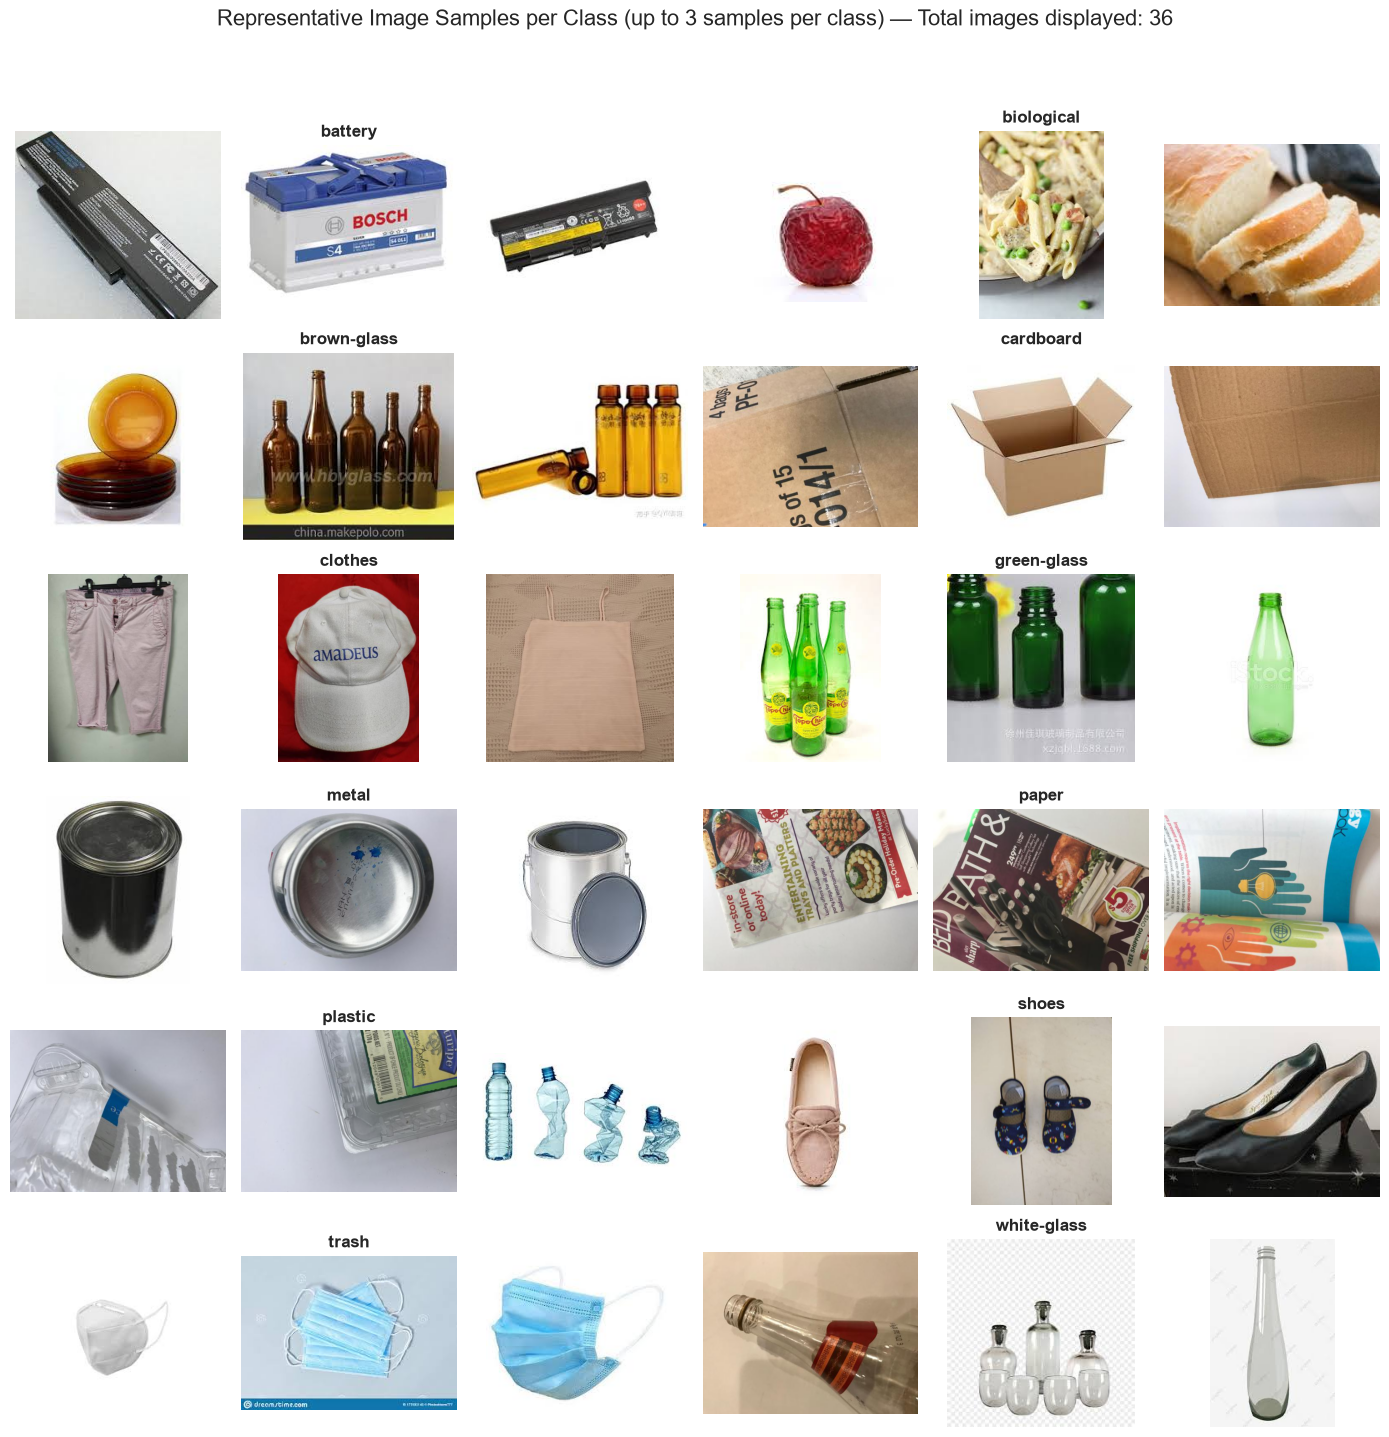

Figure berhasil disimpan di: C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\figures\preparation\three_sample_images_from_each_class.png


In [4]:
samples_per_class = 3
cols_per_row = 2

n_classes = len(CLASSES)
total_rows = (n_classes + cols_per_row - 1) // cols_per_row
ncols = samples_per_class * cols_per_row

row_height = 2.4
fig_width = 14
fig_height = max(4.5, row_height * total_rows)

fig, axes = plt.subplots(total_rows, ncols, figsize=(fig_width, fig_height))
axes = np.atleast_2d(axes)

rng = random.Random(SEED)

def pick_readable_images(paths, k, rng_obj):
    paths = list(paths)
    rng_obj.shuffle(paths)
    picked = []
    for p in paths:
        try:
            with Image.open(p) as im:
                im.convert("RGB")
            picked.append(p)
        except (UnidentifiedImageError, OSError):
            continue
        if len(picked) >= k:
            break
    return picked

shown_total = 0

for i, c in enumerate(CLASSES):
    class_dir = (RAW_DATA_DIR / c).resolve()
    if not class_dir.exists() or not class_dir.is_dir():
        continue

    imgs = [
        p for p in class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ]
    if not imgs:
        continue

    picked = pick_readable_images(imgs, samples_per_class, rng)
    if not picked:
        continue

    row_idx = i // cols_per_row
    col_start = (i % cols_per_row) * samples_per_class

    for j in range(samples_per_class):
        ax = axes[row_idx, col_start + j]
        ax.clear()
        ax.axis("off")

    for j, img_path in enumerate(picked):
        ax = axes[row_idx, col_start + j]
        ax.axis("off")
        try:
            with Image.open(img_path) as im:
                ax.imshow(im.convert("RGB"))
            shown_total += 1
        except (UnidentifiedImageError, OSError):
            pass

    title_pos = min(len(picked) - 1, len(picked) // 2)
    axes[row_idx, col_start + title_pos].set_title(
        c, fontsize=12, fontweight="bold", pad=6
    )

for ax in axes.flat:
    if not ax.has_data():
        ax.axis("off")

fig.suptitle(
    f"Representative Image Samples per Class (up to {samples_per_class} samples per class) — Total images displayed: {shown_total}",
    fontsize=16,
    y=0.995
)

fig.tight_layout(rect=[0, 0, 1, 0.96])

try:
    _root = Path(PROJECT_ROOT).resolve()
except Exception:
    _root = Path.cwd().resolve()
    for p in [_root] + list(_root.parents):
        if (p / "data" / "raw").exists() or (p / "results").exists():
            _root = p
            break

FIGURE_DIR = (_root / "results" / "figures" / "preparation").resolve()
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

out_path = FIGURE_DIR / "three_sample_images_from_each_class.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight", format="png")
plt.show()

print(f"Figure berhasil disimpan di: {out_path}")

# Stratified Splitting

In [5]:
df_all = pd.DataFrame({"filepath": all_files, "label": all_labels})
if df_all.empty:
    raise ValueError("ERROR: df_all kosong. Tidak ada file valid dari data/raw.")

def per_class_split(df, train_frac=0.70, val_frac=0.15, seed=42):
    rng = np.random.default_rng(seed)
    train_rows, val_rows, test_rows = [], [], []

    for label, g in df.groupby("label"):
        idx = g.index.to_numpy()
        rng.shuffle(idx)
        n = len(idx)

        if n == 1:
            train_rows.append(g.loc[idx])
            continue
        if n == 2:
            train_rows.append(g.loc[idx[:1]])
            test_rows.append(g.loc[idx[1:]])
            continue

        n_train = max(1, int(round(train_frac * n)))
        n_val = max(1, int(round(val_frac * n)))
        n_test = n - n_train - n_val

        if n_test < 1:
            n_test = 1
            if n_val > 1:
                n_val -= 1
            else:
                n_train = max(1, n_train - 1)

        train_rows.append(g.loc[idx[:n_train]])
        val_rows.append(g.loc[idx[n_train:n_train + n_val]])
        test_rows.append(g.loc[idx[n_train + n_val:n_train + n_val + n_test]])

    train_df = pd.concat(train_rows).sample(frac=1, random_state=seed).reset_index(drop=True)
    val_df = pd.concat(val_rows).sample(frac=1, random_state=seed).reset_index(drop=True) if val_rows else pd.DataFrame(columns=df.columns)
    test_df = pd.concat(test_rows).sample(frac=1, random_state=seed).reset_index(drop=True) if test_rows else pd.DataFrame(columns=df.columns)
    return train_df, val_df, test_df

try:
    X_train, X_temp, y_train, y_temp = train_test_split(
        df_all["filepath"], df_all["label"],
        test_size=0.30, random_state=SEED, stratify=df_all["label"]
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.50, random_state=SEED, stratify=y_temp
    )
except ValueError as e:
    print("Stratified split gagal, fallback per-kelas.")
    print(f"Alasan: {e}")
    train_df, val_df, test_df = per_class_split(df_all, seed=SEED)
    X_train, y_train = train_df["filepath"], train_df["label"]
    X_val, y_val = val_df["filepath"], val_df["label"]
    X_test, y_test = test_df["filepath"], test_df["label"]

print(f"Jumlah Data Train : {len(X_train)} ({len(X_train)/len(df_all):.1%})")
print(f"Jumlah Data Val   : {len(X_val)} ({len(X_val)/len(df_all):.1%})")
print(f"Jumlah Data Test  : {len(X_test)} ({len(X_test)/len(df_all):.1%})")

REPORT_DIR = PROJECT_ROOT / "results" / "reports" / "preparation"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"filepath": X_train, "label": y_train}).to_csv(REPORT_DIR / "train_manifest.csv", index=False)
pd.DataFrame({"filepath": X_val, "label": y_val}).to_csv(REPORT_DIR / "val_manifest.csv", index=False)
pd.DataFrame({"filepath": X_test, "label": y_test}).to_csv(REPORT_DIR / "test_manifest.csv", index=False)

Jumlah Data Train : 10860 (70.0%)
Jumlah Data Val   : 2327 (15.0%)
Jumlah Data Test  : 2328 (15.0%)


# Menyalin File

In [6]:
def assert_safe_output_dir(output_dir: Path):
    out = output_dir.resolve()
    if out.name != "split" or out.parent.name != "data":
        raise RuntimeError(f"Refuse to delete unsafe OUTPUT_DIR: {out}")

def file_hash(path: Path, chunk_size=1024 * 1024) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()[:12]

def safe_copy(src_path: str, dest_dir: Path, raw_root: Path):
    src = Path(src_path).resolve()
    raw_root = raw_root.resolve()
    dest_dir.mkdir(parents=True, exist_ok=True)

    try:
        src.relative_to(raw_root)
    except ValueError:
        raise RuntimeError(f"File di luar RAW_DATA_DIR terdeteksi (blocked): {src}")

    if not src.exists():
        raise FileNotFoundError(f"Source file tidak ditemukan: {src}")

    dest = dest_dir / src.name

    if dest.exists():
        hx = file_hash(src)
        dest = dest_dir / f"{src.stem}_{hx}{src.suffix}"

    shutil.copy2(src, dest)

def copy_files(file_list, labels, subset_name: str):
    print(f"Sedang menyalin file ke folder {subset_name}...")
    for filepath, label in tqdm(list(zip(file_list, labels)), total=len(file_list)):
        dest_dir = OUTPUT_DIR / subset_name / str(label)
        try:
            safe_copy(filepath, dest_dir, RAW_DATA_DIR)
        except Exception as e:
            print(f"[SKIP] Gagal copy {filepath} -> {dest_dir}: {e}")

if OUTPUT_DIR.exists():
    assert_safe_output_dir(OUTPUT_DIR)
    shutil.rmtree(OUTPUT_DIR)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

copy_files(X_train, y_train, "train")
copy_files(X_val, y_val, "val")
copy_files(X_test, y_test, "test")

print("\nSelesai! Data telah siap di folder 'data/split/'")
print(f"Output path: {OUTPUT_DIR}")

Sedang menyalin file ke folder train...


100%|██████████| 10860/10860 [00:12<00:00, 848.28it/s]


Sedang menyalin file ke folder val...


100%|██████████| 2327/2327 [00:02<00:00, 858.67it/s]


Sedang menyalin file ke folder test...


100%|██████████| 2328/2328 [00:02<00:00, 866.39it/s]


Selesai! Data telah siap di folder 'data/split/'
Output path: C:\Users\dwork\Downloads\Garbage_Classification_Thesis\data\split


# Verifikasi Akhir

In [7]:
stats_data = []
subsets = ["train", "val", "test"]

for c in CLASSES:
    row = {"Class": c}
    class_total = 0
    for subset in subsets:
        subset_dir = OUTPUT_DIR / subset / c
        if subset_dir.exists():
            count = sum(1 for p in subset_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS)
        else:
            count = 0
        row[subset] = count
        class_total += count
    row["Total"] = class_total
    stats_data.append(row)

df_distribution = pd.DataFrame(stats_data)

total_row = df_distribution[subsets + ["Total"]].sum(numeric_only=True)
total_row["Class"] = "TOTAL"

df_final = pd.concat([df_distribution, total_row.to_frame().T], ignore_index=True)
df_final = df_final[["Class"] + subsets + ["Total"]]

split_total = int(df_final.loc[df_final["Class"] == "TOTAL", "Total"].iloc[0])
source_total = len(df_all)
if split_total != source_total:
    print(f"WARNING: Total file di split ({split_total}) != total source ({source_total}). Ada file yang gagal dicopy/terskip.")

missing_val = df_distribution[df_distribution["val"] == 0]["Class"].tolist()
missing_test = df_distribution[df_distribution["test"] == 0]["Class"].tolist()
if missing_val:
    print("WARNING: Kelas tanpa data di VAL:", missing_val)
if missing_test:
    print("WARNING: Kelas tanpa data di TEST:", missing_test)

print("Tabel Distribusi Data per Subset:")
try:
    from IPython.display import display
    display(df_final)
except Exception:
    print(df_final.to_string(index=False))

REPORT_DIR = PROJECT_ROOT / "results" / "reports" / "preparation"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
csv_path = REPORT_DIR / "data_distribution.csv"
df_final.to_csv(csv_path, index=False)
print(f"\nTabel distribusi berhasil disimpan di: {csv_path}")

Tabel Distribusi Data per Subset:


,Class,train,val,test,Total
0,battery,661,142,142,945
1,biological,689,148,148,985
2,brown-glass,425,91,91,607
3,cardboard,624,133,134,891
4,clothes,3727,799,799,5325
5,green-glass,440,95,94,629
6,metal,538,116,115,769
7,paper,735,157,158,1050
8,plastic,606,129,130,865
9,shoes,1384,296,297,1977



Tabel distribusi berhasil disimpan di: C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\reports\preparation\data_distribution.csv
